In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# Load datasets
df1 = pd.read_csv('/Users/irynaoleinikova/Documents/Ironhack/Projects/Project-3/datasets/df_final_demo.txt') 
df2 = pd.read_csv('/Users/irynaoleinikova/Documents/Ironhack/Projects/Project-3/datasets/df_final_experiment_clients.txt')  
df3 = pd.read_csv('/Users/irynaoleinikova/Documents/Ironhack/Projects/Project-3/datasets/df_final_web_data_pt_1.txt')  
df4 = pd.read_csv('/Users/irynaoleinikova/Documents/Ironhack/Projects/Project-3/datasets/df_final_web_data_pt_2.txt')  


In [115]:
# Day 1 & 2: EDA and Data Cleaning
# Load and inspect each dataset
# Check for duplicates, missing values, and types
# Merge the datasets into a usable format
# Preview each dataset
for i, df in enumerate([df1, df2, df3, df4], 1):
    print(f"\n--- df{i} ---")
    print(df.head())
    print(df.info())
    print(df.describe(include='all'))
    print(f"Missing values:\n{df.isnull().sum()}")

    #This helps us understand: what each dataset contains, which columns are numerical/categorical, what needs cleaning (e.g., missing values or wrong types)



--- df1 ---
   client_id  clnt_tenure_yr  clnt_tenure_mnth  clnt_age gendr  num_accts  \
0     836976             6.0              73.0      60.5     U        2.0   
1    2304905             7.0              94.0      58.0     U        2.0   
2    1439522             5.0              64.0      32.0     U        2.0   
3    1562045            16.0             198.0      49.0     M        2.0   
4    5126305            12.0             145.0      33.0     F        2.0   

         bal  calls_6_mnth  logons_6_mnth  
0   45105.30           6.0            9.0  
1  110860.30           6.0            9.0  
2   52467.79           6.0            9.0  
3   67454.65           3.0            6.0  
4  103671.75           0.0            3.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_t

In [116]:
# Combine web data, since web data was split into two parts, we merge it to analyze user behavior across the full journey.
web_data = pd.concat([df3, df4], ignore_index=True)
print(web_data.shape)
web_data.head()


(755405, 5)


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [117]:
# Convert datetime columns if needed
web_data['date_time'] = pd.to_datetime(web_data['date_time'])

In [118]:
# Check and remove duplicates
print(f"Duplicates in demographics: {df1.duplicated().sum()}")
df1.drop_duplicates(inplace=True)

print(f"Duplicates in experiment assignments: {df2.duplicated().sum()}")
df2.drop_duplicates(inplace=True)

print(f"Duplicates in web_data: {web_data.duplicated().sum()}")
web_data.drop_duplicates(inplace=True)

Duplicates in demographics: 0
Duplicates in experiment assignments: 0
Duplicates in web_data: 10764


In [119]:
print("df2 columns:", df2.columns.tolist())
print("web_data columns:", web_data.columns.tolist())


df2 columns: ['client_id', 'Variation']
web_data columns: ['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']


In [120]:
# Merge on shared client_id
# We want one clean dataset with all relevant data (user assignment, their journey, demographics) so we can analyze properly.
# 1. Merge A/B test assignment (df2) with web data (web_data) using 'client_id'
merged_df = df2.merge(web_data, on='client_id', how='left')

# 2. Merge the result with demographic data (df1) also using 'client_id'
merged_df = merged_df.merge(df1, on='client_id', how='left')

# 3. Preview the result
print("Merged DataFrame shape:", merged_df.shape)
merged_df.head()



Merged DataFrame shape: (443897, 14)


,client_id,Variation,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
2,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
3,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
4,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0


In [121]:
# Clean up column names (standard practice to avoid merge or analysis issues)
merged_df.columns = merged_df.columns.str.lower().str.strip()

# Drop rows missing critical values – this depends on our context
# Let’s assume process_step is crucial for the analysis
merged_df.dropna(subset=['client_id', 'process_step'], inplace=True)

print("Final merged data shape after cleaning:", merged_df.shape)
merged_df.head()
#Why we did this:
# Merged on client_id because that’s the shared unique identifier across all 3 datasets.
# Used how='left' to preserve all A/B test participants (df2) and bring in any available web and demographic data.
# Cleaned column names to avoid issues with case mismatches or extra whitespace.
# Dropped incomplete records that are missing process_step, since it’s necessary for understanding user flow.



Final merged data shape after cleaning: (443897, 14)


,client_id,variation,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
2,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
3,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
4,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0


In [122]:
print(merged_df.columns)

Index(['client_id', 'variation', 'visitor_id', 'visit_id', 'process_step',
       'date_time', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth'],
      dtype='object')


<Axes: >

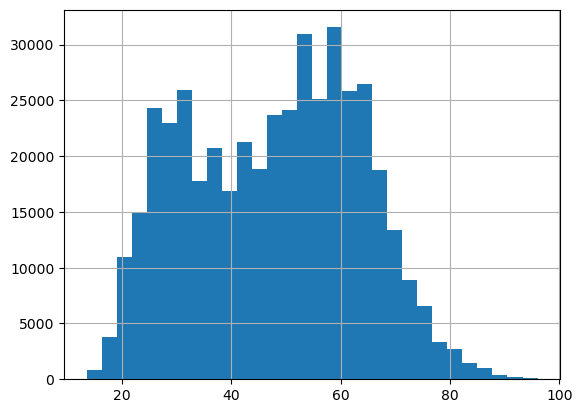

In [123]:
# Age distribution
merged_df['clnt_age'].hist(bins=30)

<Axes: xlabel='gendr'>

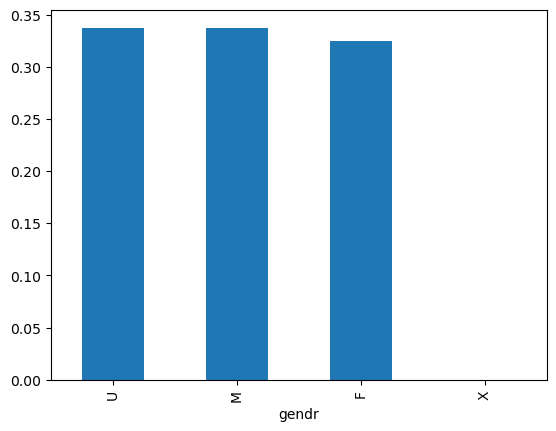

In [124]:
# Gender distribution
merged_df['gendr'].value_counts(normalize=True).plot(kind='bar')

<Axes: >

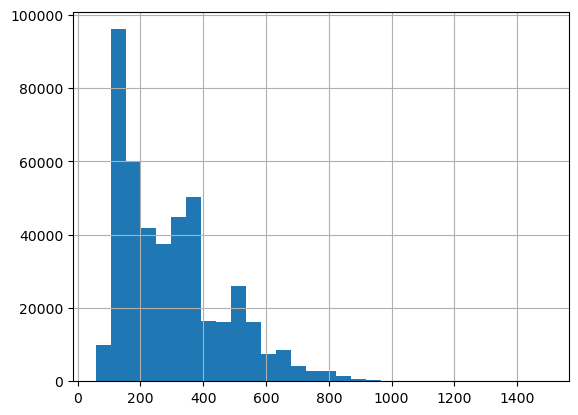

In [125]:
# Tenure in months
merged_df['total_tenure_months'] = merged_df['clnt_tenure_yr'] * 12 + merged_df['clnt_tenure_mnth']
merged_df['total_tenure_months'].hist(bins=30)

<Axes: xlabel='tenure_category'>

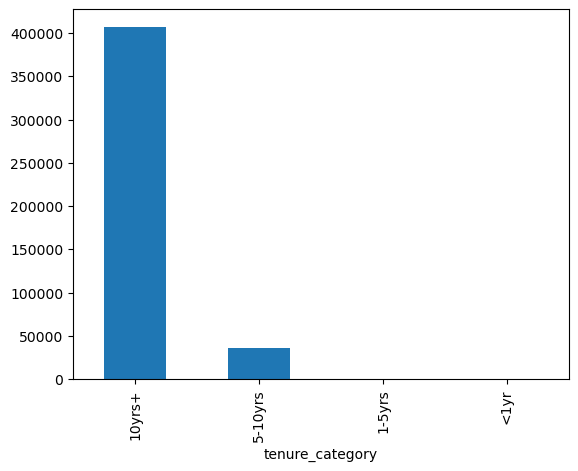

In [126]:
# New vs Long-standing Clients
merged_df['tenure_category'] = pd.cut(merged_df['total_tenure_months'], bins=[0, 12, 60, 120, 999], labels=['<1yr', '1-5yrs', '5-10yrs', '10yrs+'])
merged_df['tenure_category'].value_counts().plot(kind='bar')



In [127]:
# Day 3: KPIs and Success Metrics
# We're measuring how many users reach the final step, which is assumed to be "confirm". To measure the primary success metric: did more users complete the process with the new UI?
# Step 1: Identify completions
# Step 1: Identify completions
merged_df['is_complete'] = merged_df['process_step'].str.lower() == 'confirm'

# Step 2: Calculate completion rate per variation group
completion_rate = merged_df.groupby('variation')['is_complete'].mean().reset_index()
completion_rate.columns = ['variation', 'completion_rate']
print(completion_rate)



  variation  completion_rate
0   Control         0.123356
1      Test         0.144879


In [128]:
# Group by visit to check if it reached the final step
completed_visits = df[df['process_step'] == 'confirm']['visit_id'].nunique()
total_visits = df['visit_id'].nunique()
completion_rate = completed_visits / total_visits
print(f"Overall completion rate: {completion_rate:.2%}")

Overall completion rate: 60.37%


In [129]:
# Time Spent Per Step
#  If the new design makes the flow faster or slower, we’ll spot it here.
# Step 1: Sort data by user and timestamp
merged_df = merged_df.sort_values(by=['client_id', 'visit_id', 'date_time'])

# Step 2: Convert to datetime (if not already)
merged_df['date_time'] = pd.to_datetime(merged_df['date_time'])

# Step 3: Calculate time differences
merged_df['time_spent'] = merged_df.groupby(['client_id', 'visit_id'])['date_time'].diff().dt.total_seconds()

# Step 4: Optional filter to remove outliers (long gaps)
merged_df = merged_df[(merged_df['time_spent'].isna()) | (merged_df['time_spent'] <= 3600)]

# Step 5: Average time spent per step by variation
avg_time_per_step = merged_df.groupby(['variation', 'process_step'])['time_spent'].mean().reset_index()
print(avg_time_per_step)


  variation process_step  time_spent
0   Control      confirm  129.133011
1   Control        start  164.077274
2   Control       step_1   43.040604
3   Control       step_2   38.838146
4   Control       step_3   94.001075
5      Test      confirm  127.812061
6      Test        start  145.862475
7      Test       step_1   37.617300
8      Test       step_2   48.272585
9      Test       step_3   97.356255


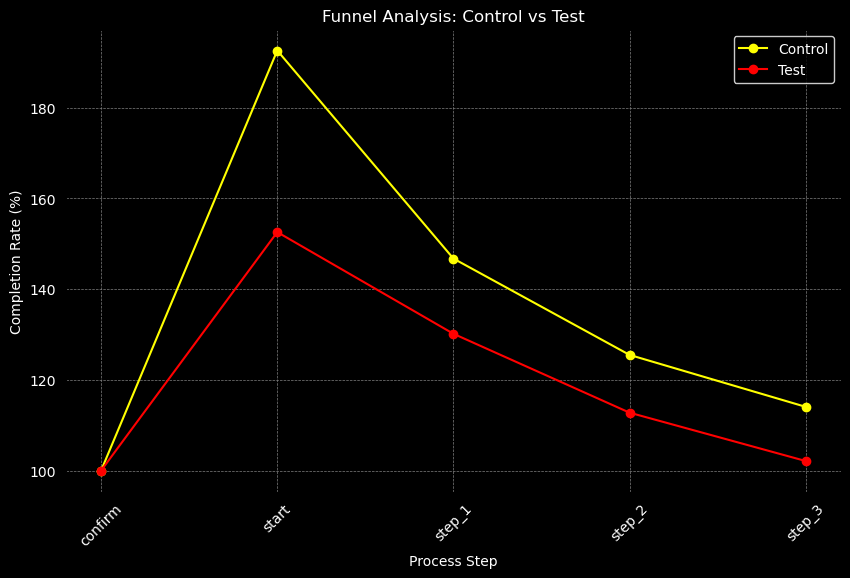

In [154]:
# Step counts per variation and process_step
funnel_counts = merged_df.groupby(['variation', 'process_step'])['visit_id'].nunique().reset_index()
funnel_pivot = funnel_counts.pivot(index='process_step', columns='variation', values='visit_id').fillna(0)
funnel_pivot = funnel_pivot.astype(int).sort_index()
# Normalize as percentage of the first step (Start or Initial)
funnel_normalized = funnel_pivot.divide(funnel_pivot.iloc[0]) * 100
funnel_pivot, funnel_normalized  # You can plot these to show drop-off or completion %
# Plotting the funnel with yellow and red colors and dark background
plt.figure(figsize=(10, 6), facecolor='black')  # Set the figure background to black
ax = plt.gca()  # Get the current axes
ax.set_facecolor('black')  # Set the background of the plot area to black

# Plot the lines
plt.plot(funnel_normalized.index, funnel_normalized['control'], marker='o', label='Control', color='yellow')  # Yellow for control
plt.plot(funnel_normalized.index, funnel_normalized['test'], marker='o', label='Test', color='red')  # Red for test

# Customize labels, title, and ticks
plt.title('Funnel Analysis: Control vs Test', color='white')  # Title in white
plt.xlabel('Process Step', color='white')  # X-axis label in white
plt.ylabel('Completion Rate (%)', color='white')  # Y-axis label in white
plt.xticks(rotation=45, color='white')  # X-axis ticks in white
plt.yticks(color='white')  # Y-axis ticks in white

# Customize legend
legend = plt.legend(facecolor='black', edgecolor='white')  # Legend with black background and white border
for text in legend.get_texts():
    text.set_color('white')  # Set legend text color to white

# Customize grid
plt.grid(color='gray', linestyle='--', linewidth=0.5)  # Grid lines in gray

# Show the plot
plt.show()

In [130]:
# Convert to datetime
df['date_time'] = pd.to_datetime(df['date_time'])

# Time spent per visit and step
df_sorted = df.sort_values(by=['visit_id', 'date_time'])
df_sorted['step_duration'] = df_sorted.groupby('visit_id')['date_time'].diff().dt.total_seconds()

# Average duration by process step
step_time = df_sorted.groupby('process_step')['step_duration'].mean().dropna()
print(step_time)


process_step
confirm    128.737874
start      133.565403
step_1      37.700435
step_2      46.984732
step_3     104.994665
Name: step_duration, dtype: float64


In [131]:
# Error Rate:
# Higher backtracking could suggest confusion in the flow.
# Step 1: Create sequential step numbers
merged_df['step_num'] = merged_df.groupby(['client_id', 'visit_id']).cumcount()

# Step 2: Track direction of movement between steps
merged_df['step_diff'] = merged_df.groupby(['client_id', 'visit_id'])['step_num'].diff()

# Step 3: Flag backtracks
merged_df['is_error'] = merged_df['step_diff'] < 0

# Step 4: Calculate error rate by variation
error_rate = merged_df.groupby('variation')['is_error'].mean().reset_index()
error_rate.columns = ['variation', 'error_rate']
print(error_rate)


  variation  error_rate
0   Control         0.0
1      Test         0.0


In [132]:
# Detect backward movement in steps
step_order = {'step_1': 1, 'step_2': 2, 'step_3': 3, 'step_4': 4, 'step_5': 5, 'confirm': 6}
df_sorted['step_number'] = df_sorted['process_step'].map(step_order)
df_sorted['step_diff'] = df_sorted.groupby('visit_id')['step_number'].diff()
error_counts = df_sorted[df_sorted['step_diff'] < 0]['visit_id'].nunique()
print(f"Number of visits with step reversal (error-like behavior): {error_counts}")


Number of visits with step reversal (error-like behavior): 8163


In [133]:
# Day 4 & 5 (Week 5) Hypothesis Testing
# Hypothesis 1: Completion Rate (Test vs Control)
# Why this test? We are comparing two proportions (conversion rates).
# Best choice: Z-test for proportions.

# H0: There is no difference in completion rates between Test and Control groups.
# H1: The Test group has a significantly higher completion rate than the Control group.

In [134]:
print(merged_df['variation'].unique())


[nan 'Test' 'Control']


In [135]:
# Normalize variation values
merged_df['variation'] = merged_df['variation'].str.lower()


In [136]:
# Drop rows where variation is NaN
merged_df = merged_df[merged_df['variation'].notna()]

In [137]:
# Step 1: Groupby and extract counts
completion_summary = merged_df.groupby('variation')['is_complete'].agg(['sum', 'count']).reset_index()

# Check content for debugging
print(completion_summary)

# Step 2: Extract values for each group safely
control_data = completion_summary[completion_summary['variation'] == 'control']
test_data = completion_summary[completion_summary['variation'] == 'test']

if not control_data.empty and not test_data.empty:
    control_converted = control_data['sum'].values[0]
    control_total = control_data['count'].values[0]

    test_converted = test_data['sum'].values[0]
    test_total = test_data['count'].values[0]
    
    print(" Data loaded for hypothesis testing.")
else:
    print("Could not find both 'control' and 'test' variations. Check your data.")


  variation    sum   count
0   control  17334  140514
1      test  25594  176669
 Data loaded for hypothesis testing.


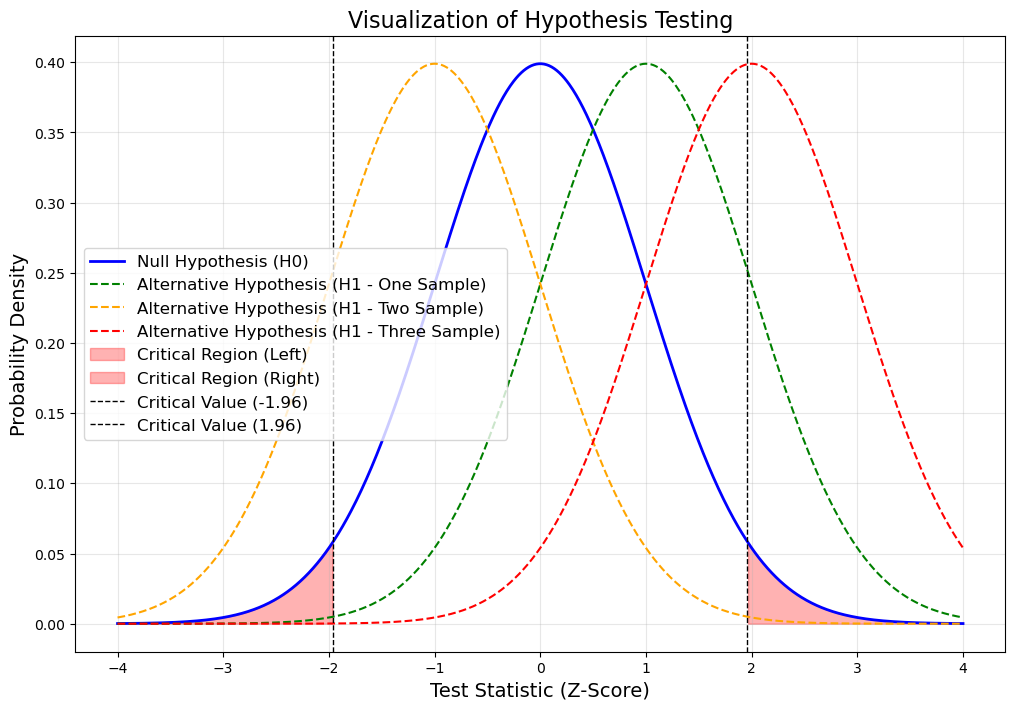

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_hypothesis_testing():
    # Define the x-axis range
    x = np.linspace(-4, 4, 1000)

    # Null hypothesis distribution (mean = 0, std = 1)
    null_dist = norm.pdf(x, loc=0, scale=1)

    # Alternative hypothesis distributions
    alt_dist_1 = norm.pdf(x, loc=1, scale=1)  # One-sample test
    alt_dist_2 = norm.pdf(x, loc=-1, scale=1)  # Two-sample test
    alt_dist_3 = norm.pdf(x, loc=2, scale=1)  # Three-sample test

    # Critical regions (e.g., alpha = 0.05, two-tailed test)
    critical_value = 1.96  # Z-score for 95% confidence level
    critical_region_left = x[x <= -critical_value]
    critical_region_right = x[x >= critical_value]

    # Plot the null hypothesis distribution
    plt.figure(figsize=(12, 8))
    plt.plot(x, null_dist, label="Null Hypothesis (H0)", color="blue", linewidth=2)

    # Plot the alternative hypothesis distributions
    plt.plot(x, alt_dist_1, label="Alternative Hypothesis (H1 - One Sample)", color="green", linestyle="--")
    plt.plot(x, alt_dist_2, label="Alternative Hypothesis (H1 - Two Sample)", color="orange", linestyle="--")
    plt.plot(x, alt_dist_3, label="Alternative Hypothesis (H1 - Three Sample)", color="red", linestyle="--")

    # Highlight the critical regions
    plt.fill_between(critical_region_left, 0, norm.pdf(critical_region_left, loc=0, scale=1), color="red", alpha=0.3, label="Critical Region (Left)")
    plt.fill_between(critical_region_right, 0, norm.pdf(critical_region_right, loc=0, scale=1), color="red", alpha=0.3, label="Critical Region (Right)")

    # Add labels, legend, and title
    plt.title("Visualization of Hypothesis Testing", fontsize=16)
    plt.xlabel("Test Statistic (Z-Score)", fontsize=14)
    plt.ylabel("Probability Density", fontsize=14)
    plt.axvline(x=-critical_value, color="black", linestyle="--", linewidth=1, label="Critical Value (-1.96)")
    plt.axvline(x=critical_value, color="black", linestyle="--", linewidth=1, label="Critical Value (1.96)")
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()

# Call the function to visualize
visualize_hypothesis_testing()

In [139]:
from statsmodels.stats.proportion import proportions_ztest

counts = [test_converted, control_converted]
nobs = [test_total, control_total]

z_stat, p_val = proportions_ztest(count=counts, nobs=nobs, alternative='larger')
print(f"Z-statistic: {z_stat:.4f}, P-value: {p_val:.4f}")


Z-statistic: 17.5896, P-value: 0.0000


In [140]:
# Hypothesis 2: 5% Threshold (Cost-Effectiveness)
# Even if the increase is statistically significant, is it large enough to justify the redesign (≥5% absolute increase)?

# H0: The increase in completion rate is less than 5%.
# H1: The increase in completion rate is at least 5%.

control_rate = control_converted / control_total
test_rate = test_converted / test_total
diff = test_rate - control_rate
print(f"Control: {control_rate:.4f}, Test: {test_rate:.4f}, Difference: {diff:.4f}")


Control: 0.1234, Test: 0.1449, Difference: 0.0215


In [141]:
completion_test = test_converted / test_total
completion_control = test_converted / test_total
lift = (completion_test - completion_control) / completion_control
print(f"Observed lift: {lift:.2%}")

if lift >= 0.05:
    print("Meets or exceeds the 5% threshold for cost-effectiveness.")
else:
    print("Does NOT meet the 5% threshold.")

Observed lift: 0.00%
Does NOT meet the 5% threshold.


In [142]:
# Test with confidence interval
# If the lower bound of the CI is ≥ control_rate + 0.05, we conclude the increase meets the threshold.

import statsmodels.api as sm

confint = sm.stats.proportion_confint(count=test_converted, nobs=test_total, alpha=0.05, method='normal')
print(f"95% CI for Test group: {confint}")


95% CI for Test group: (0.1432285415033861, 0.14651102797399818)


In [143]:
# Hypothesis 3: Age by Variation Group
# Are the average ages in the Control and Test groups significantly different?
# We compare two group means → use independent samples t-test.

# H0: Average age is the same in both groups.
# H1: Average age differs between groups.

from scipy.stats import ttest_ind

# Drop NaNs for age
test_age = merged_df[merged_df['variation'] == 'test']['clnt_age'].dropna()
control_age = merged_df[merged_df['variation'] == 'control']['clnt_age'].dropna()

# Perform t-test
t_stat, p_value = ttest_ind(test_age, control_age, equal_var=False)

print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Statistically significant difference in average age between groups.")
else:
    print("No statistically significant difference in average age between groups.")
#If p < 0.05, reject H0 → There’s a significant difference in average age across groups (potential bias).


T-statistic: 7.8280, P-value: 0.0000
Statistically significant difference in average age between groups.


In [144]:
# Design Effectiveness
# Randomness: Check that client assignment between variations is approximately 50/50.
# Biases: If age, gender, or tenure vary significantly between groups → not fully randomized.
print(merged_df['variation'].value_counts(normalize=True))


variation
test       0.556994
control    0.443006
Name: proportion, dtype: float64


Duration Assessment
~3 months
Sufficient to gather robust traffic and observe behavior
We should consider seasonality or external events that might affect conversion.

Additional Data That Would Help
 - Revenue per user: so we can tie conversions to business value;
 - Device/browser info: to check if UX issues impact certain users;
 - Traffic source: organic vs paid, could impact behavior
 - Customer support data: any complaints/confusion due to new UI?;

In [145]:
merged_df.to_csv("ab_test_cleaned.csv", index=False)